# Statistical Inference and Hypothesis Testing
### Interactive Notebook for AI/ML Interview Preparation

This notebook covers confidence intervals, hypothesis tests, p-values, Type I/II errors, MLE, and A/B testing.

📺 **Video Lecture:** [https://youtu.be/4NlWsOKGBLc](https://youtu.be/4NlWsOKGBLc)

In [2]:
# Prerequisites
# !pip install numpy scipy matplotlib seaborn pandas scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
sns.set_style('whitegrid')
np.random.seed(42)
print('Libraries loaded!')

Libraries loaded!


---
## 1. Confidence Intervals

A 95% CI means: if we repeated this experiment many times, ~95% of computed intervals would contain the true parameter.

In [3]:
# Generate sample data (e.g., heights in cm)
true_mean = 170
true_std = 10
sample = np.random.normal(true_mean, true_std, size=50)

# Compute 95% confidence interval
sample_mean = np.mean(sample)
se = stats.sem(sample)  # standard error
ci_95 = stats.t.interval(0.95, df=len(sample)-1, loc=sample_mean, scale=se)

print(f'Sample mean: {sample_mean:.2f}')
print(f'95% CI: ({ci_95[0]:.2f}, {ci_95[1]:.2f})')
print(f'True mean: {true_mean} — {"inside" if ci_95[0]<=true_mean<=ci_95[1] else "outside"} the CI')

Sample mean: 167.75
95% CI: (165.09, 170.40)
True mean: 170 — inside the CI


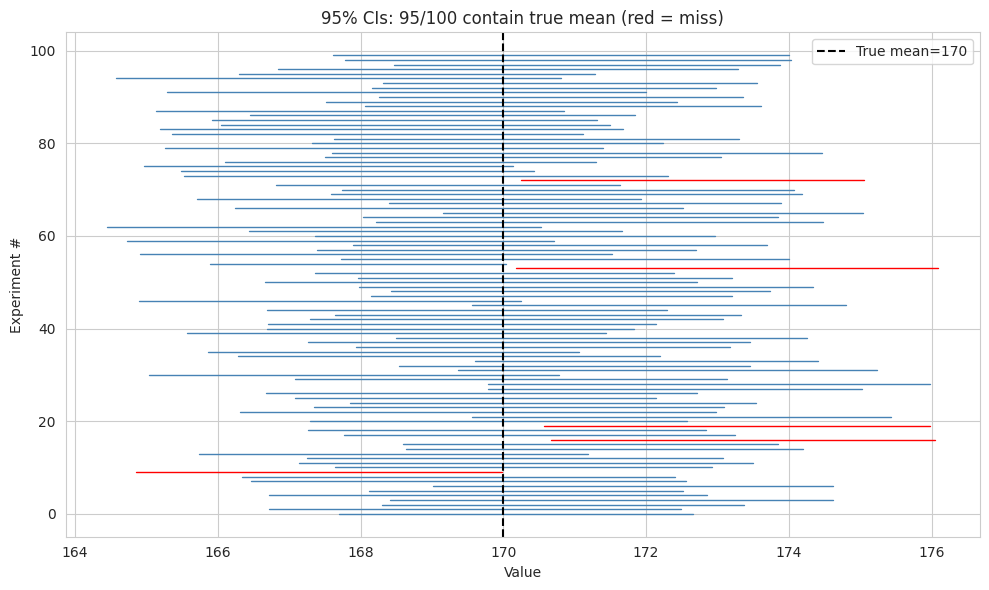

In [4]:
# Visualize: run 100 experiments, show which CIs contain the true mean
n_experiments = 100
contains_true = []
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(n_experiments):
    s = np.random.normal(true_mean, true_std, size=50)
    ci = stats.t.interval(0.95, df=49, loc=np.mean(s), scale=stats.sem(s))
    color = 'steelblue' if ci[0] <= true_mean <= ci[1] else 'red'
    contains_true.append(ci[0] <= true_mean <= ci[1])
    ax.plot([ci[0], ci[1]], [i, i], color=color, linewidth=1)
ax.axvline(x=true_mean, color='black', linestyle='--', label=f'True mean={true_mean}')
ax.set_xlabel('Value')
ax.set_ylabel('Experiment #')
ax.set_title(f'95% CIs: {sum(contains_true)}/100 contain true mean (red = miss)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Hypothesis Testing: t-tests

**Null hypothesis (H₀):** No difference between groups.  
**Alternative (H₁):** There IS a difference.  
We reject H₀ if p-value < α (typically 0.05).

Group A mean: 99.71, Group B mean: 108.73
t-statistic: -3.5581
p-value: 0.0006
Result: Reject H0 — significant difference


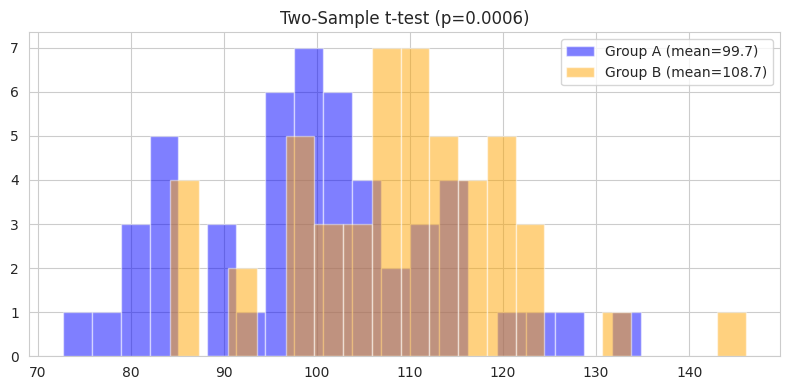

In [5]:
# Two-sample t-test: Do two groups have different means?
group_a = np.random.normal(100, 15, size=50)  # Control
group_b = np.random.normal(108, 15, size=50)  # Treatment (true diff = 8)

t_stat, p_value = stats.ttest_ind(group_a, group_b)
print(f'Group A mean: {group_a.mean():.2f}, Group B mean: {group_b.mean():.2f}')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'Result: {"Reject H0 — significant difference" if p_value < 0.05 else "Fail to reject H0"}')

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(group_a, bins=20, alpha=0.5, label=f'Group A (mean={group_a.mean():.1f})', color='blue')
ax.hist(group_b, bins=20, alpha=0.5, label=f'Group B (mean={group_b.mean():.1f})', color='orange')
ax.legend()
ax.set_title(f'Two-Sample t-test (p={p_value:.4f})')
plt.tight_layout()
plt.show()

---
## 3. Type I and Type II Errors

| | H₀ True | H₀ False |
|---|---|---|
| **Reject H₀** | Type I Error (α) | Correct (Power) |
| **Fail to Reject** | Correct | Type II Error (β) |

Type I error rate: 62/1000 = 6.2%
Expected at alpha=0.05: ~5%


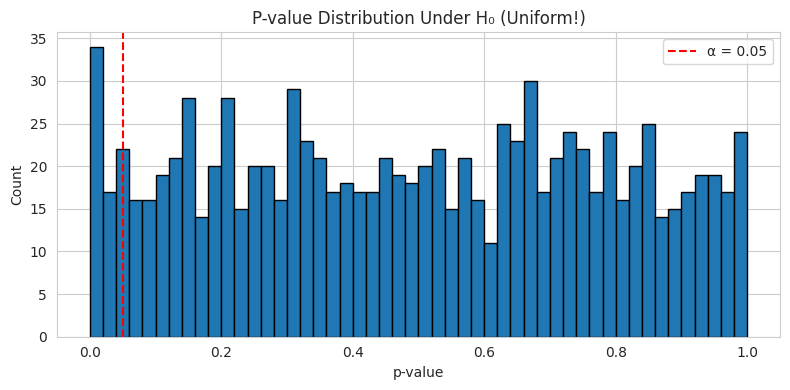

In [6]:
# Type I error demo: test 1000 times when H0 is TRUE (no real effect)
n_tests = 1000
p_values_null = []
for _ in range(n_tests):
    a = np.random.normal(100, 15, 50)
    b = np.random.normal(100, 15, 50)  # Same mean! H0 is true
    _, p = stats.ttest_ind(a, b)
    p_values_null.append(p)

false_positives = sum(p < 0.05 for p in p_values_null)
print(f'Type I error rate: {false_positives}/{n_tests} = {false_positives/n_tests:.1%}')
print(f'Expected at alpha=0.05: ~5%')

plt.figure(figsize=(8, 4))
plt.hist(p_values_null, bins=50, edgecolor='black')
plt.axvline(x=0.05, color='red', linestyle='--', label='α = 0.05')
plt.xlabel('p-value')
plt.ylabel('Count')
plt.title('P-value Distribution Under H₀ (Uniform!)')
plt.legend()
plt.tight_layout()
plt.show()

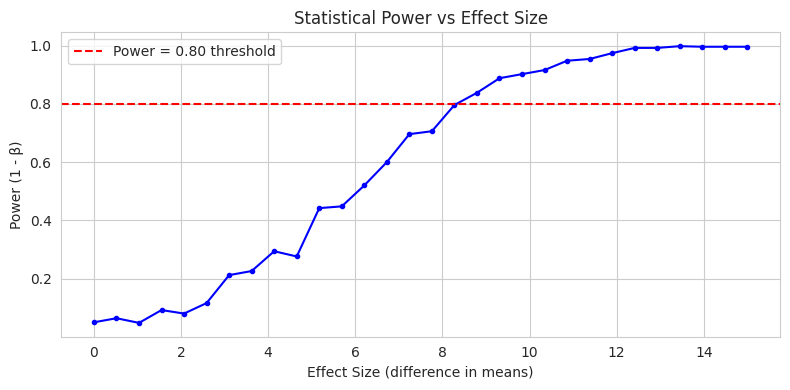

In [7]:
# Power curve: how power changes with effect size
effect_sizes = np.linspace(0, 15, 30)
powers = []
for effect in effect_sizes:
    rejections = 0
    for _ in range(500):
        a = np.random.normal(100, 15, 50)
        b = np.random.normal(100 + effect, 15, 50)
        _, p = stats.ttest_ind(a, b)
        if p < 0.05: rejections += 1
    powers.append(rejections / 500)

plt.figure(figsize=(8, 4))
plt.plot(effect_sizes, powers, 'b-o', markersize=3)
plt.axhline(y=0.8, color='red', linestyle='--', label='Power = 0.80 threshold')
plt.xlabel('Effect Size (difference in means)')
plt.ylabel('Power (1 - β)')
plt.title('Statistical Power vs Effect Size')
plt.legend()
plt.tight_layout()
plt.show()

---
## 4. Maximum Likelihood Estimation (MLE)

MLE finds the parameter values that maximize the probability of observing the data we have.

True parameters: μ=5.0, σ=2.0
MLE estimates:   μ=4.7969, σ=2.2211


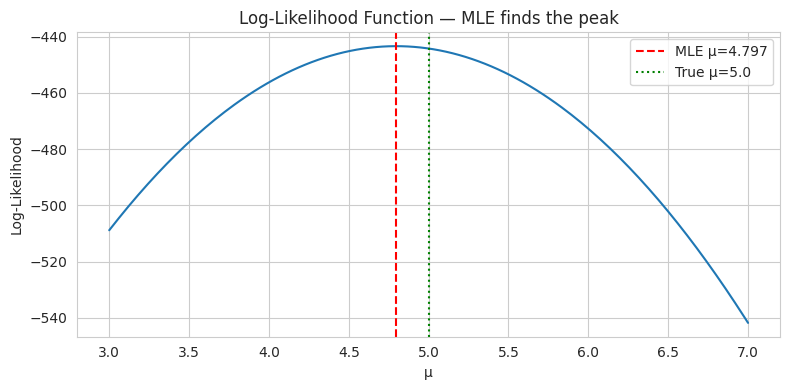

In [8]:
# MLE for Normal distribution
true_mu, true_sigma = 5.0, 2.0
data = np.random.normal(true_mu, true_sigma, 200)

# MLE estimates (for normal: MLE_mu = sample mean, MLE_sigma = sample std)
mle_mu = np.mean(data)
mle_sigma = np.std(data)  # MLE uses N, not N-1

print(f'True parameters: μ={true_mu}, σ={true_sigma}')
print(f'MLE estimates:   μ={mle_mu:.4f}, σ={mle_sigma:.4f}')

# Visualize: log-likelihood surface for mu
mu_range = np.linspace(3, 7, 200)
log_likelihoods = [np.sum(stats.norm.logpdf(data, loc=mu, scale=mle_sigma)) for mu in mu_range]

plt.figure(figsize=(8, 4))
plt.plot(mu_range, log_likelihoods)
plt.axvline(x=mle_mu, color='red', linestyle='--', label=f'MLE μ={mle_mu:.3f}')
plt.axvline(x=true_mu, color='green', linestyle=':', label=f'True μ={true_mu}')
plt.xlabel('μ')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood Function — MLE finds the peak')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. A/B Test Simulation

Simulate a website A/B test: does a new button color increase conversion rate?

In [9]:
# A/B test simulation
n_a, n_b = 1000, 1000
true_rate_a = 0.10  # Control: 10% conversion
true_rate_b = 0.12  # Treatment: 12% conversion

conversions_a = np.random.binomial(1, true_rate_a, n_a)
conversions_b = np.random.binomial(1, true_rate_b, n_b)

rate_a = conversions_a.mean()
rate_b = conversions_b.mean()
lift = (rate_b - rate_a) / rate_a * 100

# Two-proportion z-test
p_pool = (conversions_a.sum() + conversions_b.sum()) / (n_a + n_b)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n_a + 1/n_b))
z_stat = (rate_b - rate_a) / se_pool
p_val = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print('=== A/B Test Results ===')
print(f'Control (A): {rate_a:.1%} conversion ({conversions_a.sum()}/{n_a})')
print(f'Treatment (B): {rate_b:.1%} conversion ({conversions_b.sum()}/{n_b})')
print(f'Lift: {lift:.1f}%')
print(f'Z-statistic: {z_stat:.3f}')
print(f'P-value: {p_val:.4f}')
print(f'Significant at α=0.05? {"Yes" if p_val < 0.05 else "No"}')

=== A/B Test Results ===
Control (A): 9.4% conversion (94/1000)
Treatment (B): 11.5% conversion (115/1000)
Lift: 22.3%
Z-statistic: 1.535
P-value: 0.1248
Significant at α=0.05? No


---
## 6. Multiple Testing Correction

When running many tests, false positives accumulate. Bonferroni correction divides α by the number of tests.

In [10]:
# Multiple testing: run 20 tests, all under H0
n_tests = 20
alpha = 0.05
p_vals = [stats.ttest_ind(np.random.normal(0,1,30), np.random.normal(0,1,30))[1]
          for _ in range(n_tests)]

# Without correction
sig_uncorrected = sum(p < alpha for p in p_vals)
# With Bonferroni
bonferroni_alpha = alpha / n_tests
sig_corrected = sum(p < bonferroni_alpha for p in p_vals)

print(f'Running {n_tests} tests (all null true):')
print(f'  Significant without correction (α={alpha}): {sig_uncorrected}')
print(f'  Significant with Bonferroni (α={bonferroni_alpha:.4f}): {sig_corrected}')
print(f'  Bonferroni reduces false discoveries!')

Running 20 tests (all null true):
  Significant without correction (α=0.05): 0
  Significant with Bonferroni (α=0.0025): 0
  Bonferroni reduces false discoveries!


---
## Key Interview Takeaways

1. **Confidence intervals** — 95% CI means 95% of such intervals contain the true value
2. **p-value** — probability of seeing data this extreme IF H₀ is true (not probability H₀ is true!)
3. **Type I error** — false positive; controlled by α
4. **Type II error** — false negative; reduced by increasing power (larger n, larger effect)
5. **MLE** — finds parameters maximizing likelihood of observed data
6. **A/B testing** — compare conversion rates with z-test; watch for multiple testing issues

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>